# Análise Exploratória de Dados

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Nesta aula, estudaremos os principais passos da **Análise Exploratória de Dados** (*Exploratory Data Analysis*, EDA). A EDA é uma etapa essencial em Ciência de Dados, pois permite compreender a estrutura dos dados antes da modelagem estatística ou do uso de algoritmos de aprendizado de máquina.


## Objetivos de aprendizagem

Ao final desta aula, espera-se que você seja capaz de:

1. construir visualizações simples para variáveis numéricas e categóricas;
2. interpretar histogramas, gráficos de barras, boxplots, violin plots e scatterplots;
3. calcular e interpretar medidas de posição, como média, mediana, moda e quantis;
4. calcular e interpretar medidas de dispersão, como variância, desvio-padrão, amplitude e intervalo interquartil;
5. usar o método `describe()` do Pandas para obter um resumo estatístico dos dados;
6. calcular e interpretar correlações de Pearson e Spearman;
7. compreender por que gráficos são indispensáveis, mesmo quando medidas estatísticas parecem semelhantes.


## 0. Preparação do ambiente

Antes de iniciar a análise, importamos as bibliotecas que serão utilizadas ao longo da aula.

- **NumPy**: operações numéricas e geração de dados artificiais;
- **Pandas**: organização e manipulação de dados em tabelas;
- **Matplotlib** e **Seaborn**: construção de gráficos;
- **SciPy**: funções estatísticas;
- **Scikit-learn**: carregamento da base de dados Iris.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from scipy.stats import iqr, pearsonr, spearmanr
from sklearn.datasets import load_iris

# Configurações gerais para melhorar a aparência dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["font.size"] = 12

# Fixamos a semente aleatória para tornar os exemplos reprodutíveis
np.random.seed(42)

## 1. Visualização de dados

A visualização é uma das primeiras etapas da análise exploratória. Gráficos ajudam a identificar padrões, assimetrias, valores extremos (*outliers*), agrupamentos e possíveis relações entre variáveis.

Nesta seção, veremos exemplos de gráficos para:

- variáveis numéricas;
- variáveis categóricas;
- relações entre duas variáveis;
- matrizes e correlações.


### 1.1 Histograma de frequências

O histograma mostra como os valores de uma variável numérica estão distribuídos. No eixo horizontal aparecem intervalos de valores, chamados de **classes** ou *bins*. No eixo vertical aparece a frequência de observações em cada intervalo.


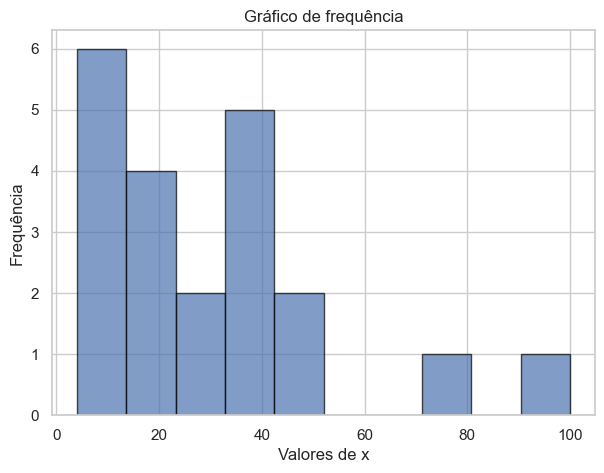

In [4]:
x = [21, 22, 23, 4, 5, 6, 77, 8, 9, 10,
     31, 32, 33, 34, 35, 36, 37, 18, 49, 50, 100]

plt.figure(figsize=(7, 5))
plt.hist(x, bins=10, density=False, edgecolor="black", alpha=0.7)
plt.xlabel("Valores de x")
plt.ylabel("Frequência")
plt.title("Gráfico de frequência")
plt.show()

No gráfico acima, a altura de cada barra representa o número de observações em cada intervalo. Esse tipo de gráfico é útil para verificar se os dados são concentrados em uma região, se há assimetria ou se existem valores muito distantes dos demais.


### 1.2 Histograma normalizado

Também podemos construir um histograma normalizado, em que a área total sob as barras é igual a 1. Nesse caso, o eixo vertical passa a representar uma **densidade**, e não mais a frequência absoluta.


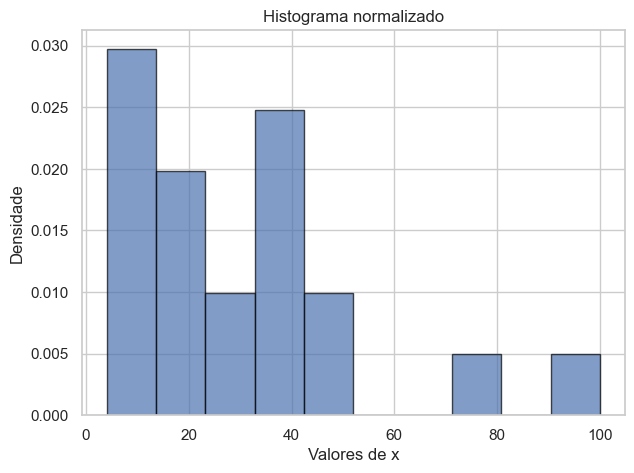

In [5]:
plt.figure(figsize=(7, 5))
plt.hist(x, bins=10, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Valores de x")
plt.ylabel("Densidade")
plt.title("Histograma normalizado")
plt.show()

A diferença entre os dois histogramas está na escala do eixo vertical. No primeiro caso, contamos observações. No segundo, representamos uma aproximação da distribuição de probabilidade dos dados.


### 1.3 Gráfico de barras para variáveis categóricas

Para variáveis categóricas, como respostas do tipo “Bom”, “Regular” ou “Ótimo”, usamos gráficos de barras. Eles mostram quantas vezes cada categoria aparece nos dados.


Bom        3
Regular    2
Ruim       1
Ótimo      5
Name: count, dtype: int64


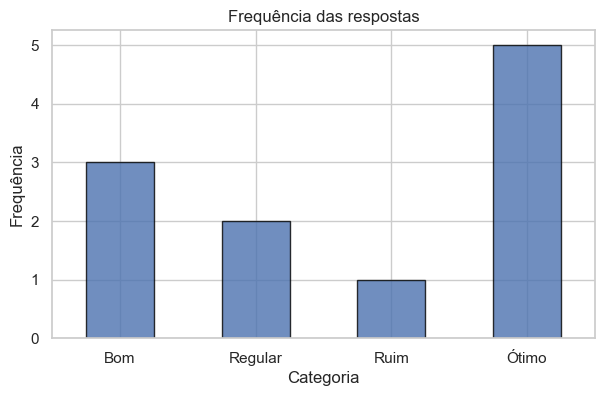

In [6]:
respostas = ["Bom", "Ruim", "Ótimo", "Regular", "Regular", "Ótimo",
             "Ótimo", "Bom", "Ótimo", "Bom", "Ótimo"]

frequencias = pd.Series(respostas).value_counts().sort_index()
print(frequencias)

plt.figure(figsize=(7, 4))
frequencias.plot(kind="bar", edgecolor="black", alpha=0.8)
plt.xlabel("Categoria")
plt.ylabel("Frequência")
plt.title("Frequência das respostas")
plt.xticks(rotation=0)
plt.show()

O gráfico de barras permite identificar rapidamente a categoria mais frequente. Nesse exemplo, a categoria “Ótimo” aparece mais vezes.


### 1.4 Gráfico de setores

O gráfico de setores, também conhecido como gráfico de pizza, mostra a proporção de cada categoria em relação ao total. Ele pode ser útil quando há poucas categorias, mas deve ser usado com cuidado, pois diferenças pequenas podem ser difíceis de comparar visualmente.


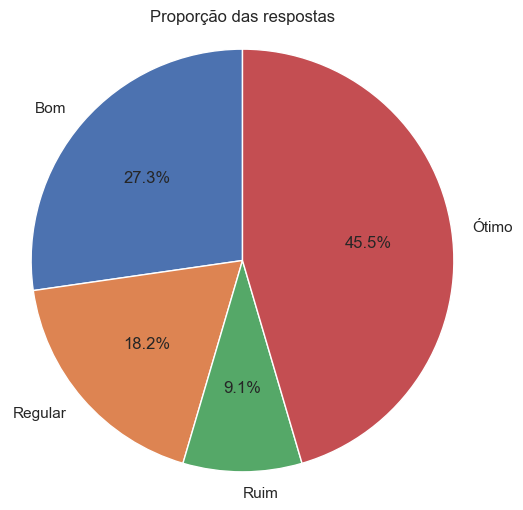

In [7]:
plt.figure(figsize=(6, 6))
plt.pie(
    frequencias.values,
    labels=frequencias.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proporção das respostas")
plt.axis("equal")
plt.show()

### 1.5 Scatterplot

O **scatterplot**, ou gráfico de dispersão, é usado para estudar a relação entre duas variáveis numéricas. Cada ponto representa uma observação.


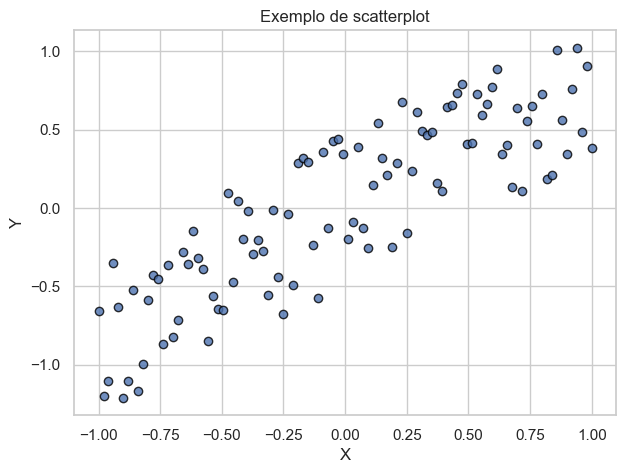

In [10]:
N = 100
X = np.linspace(-1, 1, N)
ruido = np.random.uniform(-1, 1, N)
sigma = 0.5
Y = 0.8 * X + sigma * ruido

plt.figure(figsize=(7, 5))
plt.scatter(X, Y, edgecolor="black", alpha=0.8)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exemplo de scatterplot")
plt.grid(True)
plt.show()

Nesse exemplo, existe uma tendência crescente: valores maiores de `X` tendem a estar associados a valores maiores de `Y`. No entanto, a presença de ruído faz com que os pontos não estejam exatamente sobre uma reta.


### 1.6 Mapa de calor

Um mapa de calor (*heatmap*) representa valores numéricos por meio de cores. Esse tipo de gráfico é muito usado para visualizar matrizes, como matrizes de correlação, matrizes de distância ou matrizes de adjacência em redes.


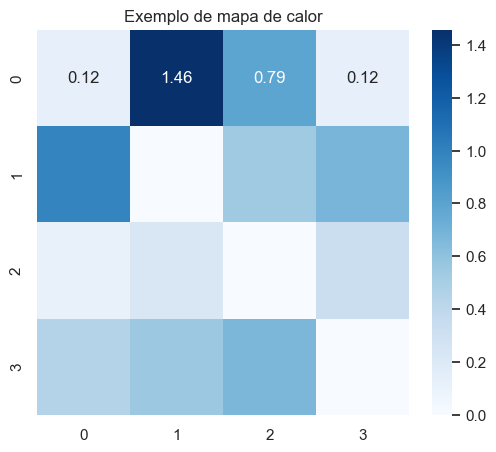

In [11]:
matriz = np.array([
    [0.1234, 1.4567, 0.7890, 0.1234],
    [0.9876, 0.0000, 0.5432, 0.6789],
    [0.1111, 0.2222, 0.0000, 0.3333],
    [0.4444, 0.5555, 0.6666, 0.0000]
])

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="Blues")
plt.title("Exemplo de mapa de calor")
plt.show()

## 2. Medidas de posição

As medidas de posição resumem onde os dados estão localizados. As principais medidas são:

- **moda**: valor mais frequente;
- **média**: soma dos valores dividida pelo número de observações;
- **mediana**: valor central quando os dados são ordenados;
- **quantis**: valores que dividem os dados em partes.


### 2.1 Moda

A moda é o valor que aparece com maior frequência em um conjunto de dados. Ela pode ser usada tanto para variáveis numéricas quanto para variáveis categóricas.


In [12]:
X = [1, 2, 3, 1, 2, 3, 4, 1, 3, 6, 4, 1]

contagem = Counter(X)
moda = contagem.most_common(1)[0]

print("Dados:", X)
print("Frequências:", contagem)
print(f"Moda: {moda[0]} — aparece {moda[1]} vezes")

Dados: [1, 2, 3, 1, 2, 3, 4, 1, 3, 6, 4, 1]
Frequências: Counter({1: 4, 3: 3, 2: 2, 4: 2, 6: 1})
Moda: 1 — aparece 4 vezes


Em alguns conjuntos de dados, pode haver mais de uma moda. Nesse caso, dizemos que a distribuição é **multimodal**.


In [17]:
X = [1, 1, 2, 2, 3]

contagem = Counter(X)
maior_frequencia = max(contagem.values())
modas = [valor for valor, freq in contagem.items() if freq == maior_frequencia]

print("Dados:", X)
print("Frequências:", contagem)
print("Modas:", modas)

Dados: [1, 1, 2, 2, 3]
Frequências: Counter({1: 2, 2: 2, 3: 1})
Modas: [1, 2]


Também podemos visualizar a moda por meio de um gráfico de barras.


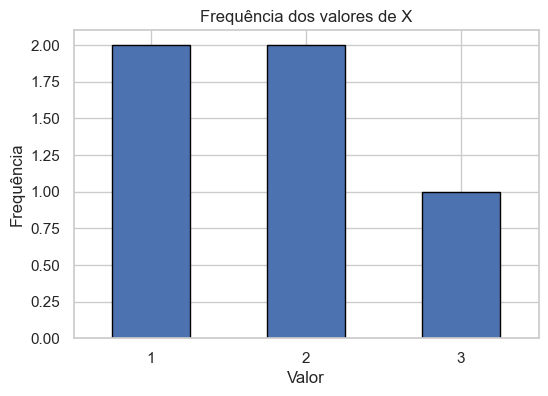

In [18]:
frequencias_X = pd.Series(X).value_counts().sort_index()

plt.figure(figsize=(6, 4))
frequencias_X.plot(kind="bar", edgecolor="black")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.title("Frequência dos valores de X")
plt.xticks(rotation=0)
plt.show()

### 2.2 Média e mediana

A média é uma medida muito usada, mas pode ser fortemente influenciada por valores extremos. A mediana, por outro lado, é mais robusta, pois depende da posição central dos dados ordenados.


In [19]:
X = [1, 1, 1, 2, 2, 3, 4, 5, 5, 5]

print("Dados:", X)
print("Média:", np.mean(X))
print("Mediana:", np.median(X))

Dados: [1, 1, 1, 2, 2, 3, 4, 5, 5, 5]
Média: 2.9
Mediana: 2.5


Agora vamos substituir um dos valores por um valor extremo. Esse exemplo mostra como a média pode mudar bastante quando há *outliers*.


In [20]:
X2 = [1, 1, 1, 2, 2, 3, 4, 5, 5, 5*20]

print("Dados com valor extremo:", X2)
print("Média:", np.mean(X2))
print("Mediana:", np.median(X2))

Dados com valor extremo: [1, 1, 1, 2, 2, 3, 4, 5, 5, 100]
Média: 12.4
Mediana: 2.5


Observe que a média aumentou muito, enquanto a mediana mudou pouco. Por isso, em distribuições assimétricas ou com valores extremos, a mediana pode ser uma medida mais representativa do centro dos dados.


### 2.3 Média e mediana em distribuições diferentes

Em distribuições aproximadamente simétricas, como a normal, média e mediana tendem a ser próximas. Em distribuições assimétricas, como a exponencial, elas podem ser bem diferentes.


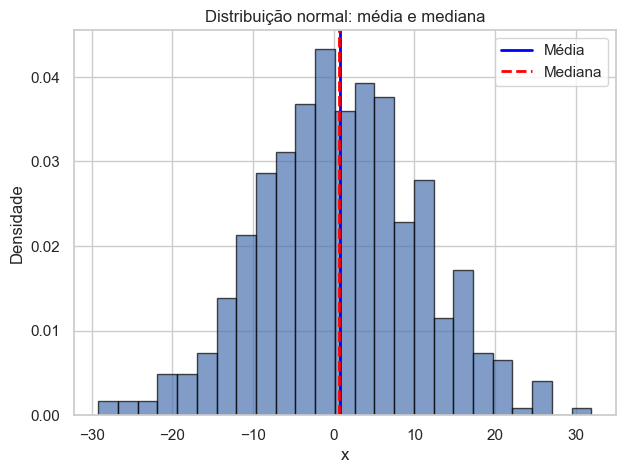

In [23]:
Y_normal = np.random.normal(loc=0, scale=10, size=500)

media_normal = np.mean(Y_normal)
mediana_normal = np.median(Y_normal)

plt.figure(figsize=(7, 5))
plt.hist(Y_normal, bins=25, density=True, edgecolor="black", alpha=0.7)
plt.axvline(media_normal, color = 'blue', label="Média", linewidth=2)
plt.axvline(mediana_normal, color = 'red', label="Mediana", linewidth=2, linestyle="--")
plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Distribuição normal: média e mediana")
plt.legend()
plt.show()

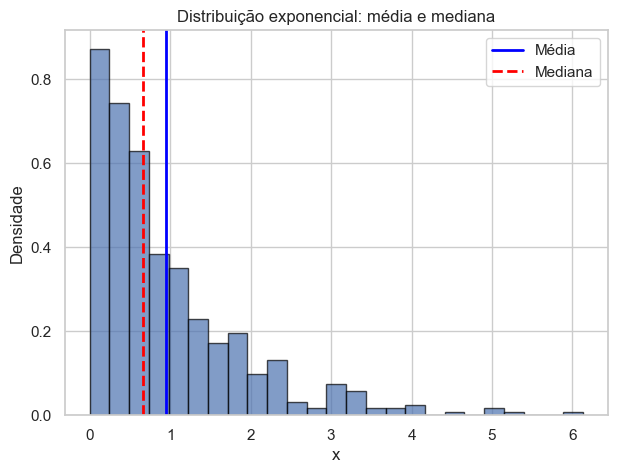

In [24]:
Y_exp = np.random.exponential(scale=1, size=500)

media_exp = np.mean(Y_exp)
mediana_exp = np.median(Y_exp)

plt.figure(figsize=(7, 5))
plt.hist(Y_exp, bins=25, density=True, edgecolor="black", alpha=0.7)
plt.axvline(media_exp, color = 'blue', label="Média", linewidth=2)
plt.axvline(mediana_exp, color = 'red',label="Mediana", linewidth=2, linestyle="--")
plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Distribuição exponencial: média e mediana")
plt.legend()
plt.show()

### 2.4 Quantis

Os quantis dividem os dados ordenados em partes. Alguns quantis importantes são:

- primeiro quartil, ou $Q_1$: 25% dos dados estão abaixo desse valor;
- mediana, ou $Q_2$: 50% dos dados estão abaixo desse valor;
- terceiro quartil, ou $Q_3$: 75% dos dados estão abaixo desse valor.

O intervalo interquartil é definido por:

$$
IQR = Q_3 - Q_1.
$$


In [25]:
x = [1, 1, 1, 2, 2, 3, 4, 5, 5, 100]

q1 = np.quantile(x, 0.25)
q2 = np.quantile(x, 0.50)
q3 = np.quantile(x, 0.75)

print("Dados:", x)
print("Média:", np.mean(x))
print("Mediana:", np.median(x))
print("Primeiro quartil Q1:", q1)
print("Segundo quartil Q2:", q2)
print("Terceiro quartil Q3:", q3)
print("Intervalo interquartil IQR:", q3 - q1)

Dados: [1, 1, 1, 2, 2, 3, 4, 5, 5, 100]
Média: 12.4
Mediana: 2.5
Primeiro quartil Q1: 1.25
Segundo quartil Q2: 2.5
Terceiro quartil Q3: 4.75
Intervalo interquartil IQR: 3.5


### 2.5 Boxplot

O boxplot resume a distribuição dos dados usando quartis. Ele mostra a mediana, o intervalo interquartil e possíveis valores extremos.


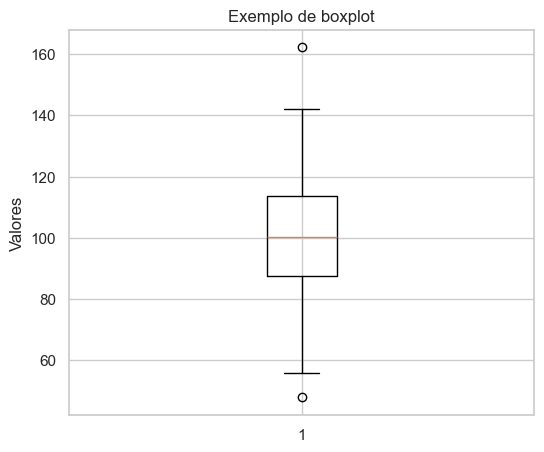

In [26]:
dados = np.random.normal(loc=100, scale=20, size=200)

plt.figure(figsize=(6, 5))
plt.boxplot(dados, vert=True)
plt.ylabel("Valores")
plt.title("Exemplo de boxplot")
plt.show()

## 3. Exemplo com base de dados real: Iris

A base Iris é um conjunto clássico de dados em Estatística e Ciência de Dados. Ela contém medidas de flores de três espécies:

- *setosa*;
- *versicolor*;
- *virginica*.

As variáveis medidas são:

- comprimento da sépala;
- largura da sépala;
- comprimento da pétala;
- largura da pétala.

Usaremos essa base para ilustrar gráficos e medidas estatísticas em um conjunto real.


In [27]:
iris = load_iris(as_frame=True)
data = iris.frame.copy()

data["species"] = data["target"].map(dict(enumerate(iris.target_names)))
data = data.drop(columns="target")

# Renomeamos as colunas para facilitar a leitura.
data = data.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width"
})

data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 3.1 Boxplot por espécie

Agora vamos comparar o comprimento das pétalas entre as três espécies. Esse gráfico permite verificar se as espécies possuem distribuições diferentes para essa variável.


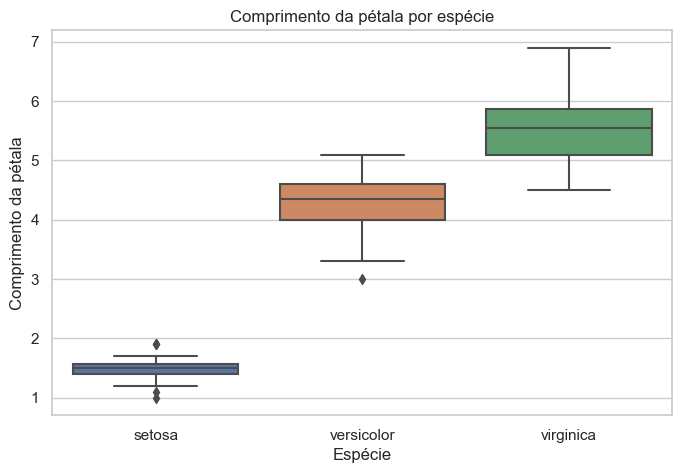

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="species", y="petal_length")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da pétala")
plt.title("Comprimento da pétala por espécie")
plt.show()

### 3.2 Violin plot

O violin plot combina informações do boxplot com uma estimativa da densidade dos dados. Ele ajuda a visualizar a forma da distribuição em cada grupo.


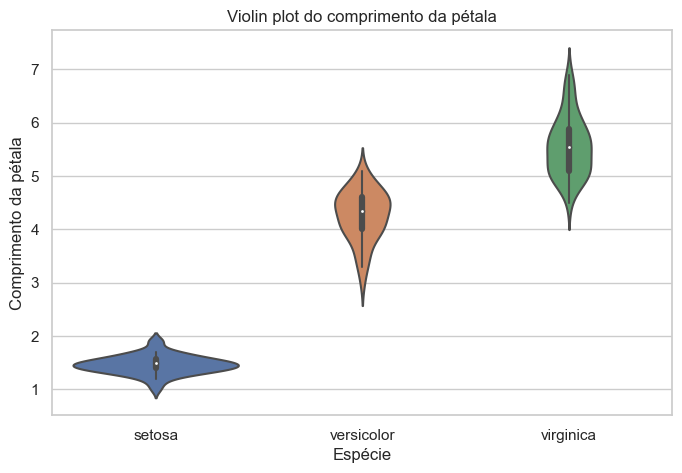

In [29]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=data, x="species", y="petal_length")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da pétala")
plt.title("Violin plot do comprimento da pétala")
plt.show()

### 3.3 Swarm plot

O swarm plot mostra cada observação individualmente. Ele é útil quando queremos visualizar a dispersão dos pontos dentro de cada grupo.


/Users/franciscoaparecidorodrigues/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/franciscoaparecidorodrigues/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/franciscoaparecidorodrigues/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


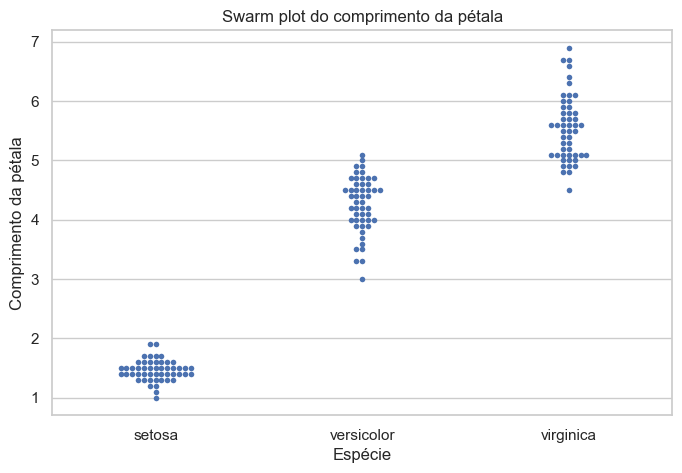

In [30]:
plt.figure(figsize=(8, 5))
sns.swarmplot(data=data, x="species", y="petal_length", size=4)
plt.xlabel("Espécie")
plt.ylabel("Comprimento da pétala")
plt.title("Swarm plot do comprimento da pétala")
plt.show()

## 4. Medidas de dispersão

As medidas de dispersão indicam o quanto os dados variam em torno de uma medida central. Duas amostras podem ter a mesma média, mas apresentar dispersões muito diferentes.

As principais medidas de dispersão são:

- **amplitude**: diferença entre o maior e o menor valor;
- **variância**: média dos desvios quadráticos em relação à média;
- **desvio-padrão**: raiz quadrada da variância;
- **intervalo interquartil**: diferença entre o terceiro e o primeiro quartil.


In [31]:
def variancia_amostral(valores):
    # Calcula a variância amostral usando denominador n - 1.
    valores = np.asarray(valores)
    media = np.mean(valores)
    return np.sum((valores - media) ** 2) / (len(valores) - 1)

X = [0, 0, 1, 1, 18]
Y = [4, 4, 4, 4, 4]

for nome, valores in [("X", X), ("Y", Y)]:
    print(f"Conjunto {nome}:", valores)
    print("Média:", np.mean(valores))
    print("Variância amostral:", variancia_amostral(valores))
    print("Desvio-padrão amostral:", np.std(valores, ddof=1))
    print("IQR:", iqr(valores))
    print("Amplitude:", np.max(valores) - np.min(valores))
    print()

Conjunto X: [0, 0, 1, 1, 18]
Média: 4.0
Variância amostral: 61.5
Desvio-padrão amostral: 7.842193570679061
IQR: 1.0
Amplitude: 18

Conjunto Y: [4, 4, 4, 4, 4]
Média: 4.0
Variância amostral: 0.0
Desvio-padrão amostral: 0.0
IQR: 0.0
Amplitude: 0



Embora os dois conjuntos tenham média igual a 4, a dispersão é muito diferente. O conjunto `Y` não varia, enquanto `X` possui um valor extremo que aumenta a variância e a amplitude.


## 5. Resumo descritivo com Pandas

O método `describe()` fornece um resumo estatístico das variáveis numéricas de um `DataFrame`. Ele apresenta contagem, média, desvio-padrão, mínimo, quartis e máximo.


In [32]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Também podemos obter o resumo por grupos. Abaixo, calculamos estatísticas separadamente para cada espécie da base Iris.


In [33]:
data.groupby("species").describe().T

species                setosa  versicolor  virginica
sepal_length count  50.000000   50.000000  50.000000
             mean    5.006000    5.936000   6.588000
             std     0.352490    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
sepal_width  count  50.000000   50.000000  50.000000
             mean    3.428000    2.770000   2.974000
             std     0.379064    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
petal_length count  50.000000   50.000000  50.000000
             mean    1.462000    4.260000   5.552000
             std     0.173664    0.469911   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
petal_width  count  50.000000   50.000000  50.000000
             mean    0.246000    1.326000   2.026000
             std     0.105386    0.197753   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000

## 6. Correlação

A correlação mede a associação entre duas variáveis. Ela é útil para investigar se duas variáveis tendem a variar juntas.

Nesta aula, veremos duas medidas:

- **correlação de Pearson**: mede associação linear;
- **correlação de Spearman**: mede associação monotônica, usando os postos dos dados.

Importante: correlação não implica causalidade. Duas variáveis podem estar correlacionadas sem que uma cause a outra.


### 6.1 Correlação de Pearson

A correlação de Pearson varia entre -1 e 1:

- valores próximos de 1 indicam associação linear positiva;
- valores próximos de -1 indicam associação linear negativa;
- valores próximos de 0 indicam ausência de associação linear.


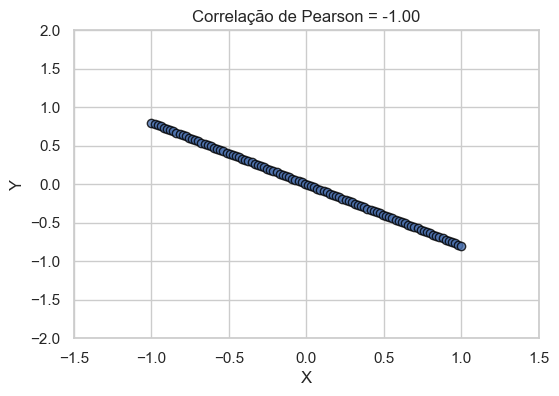

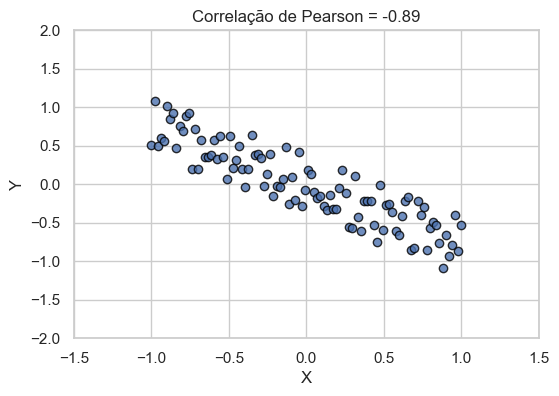

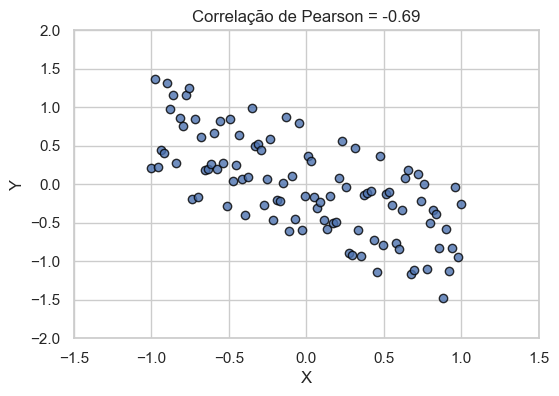

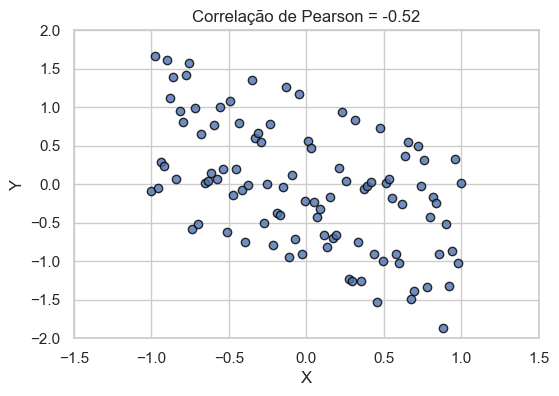

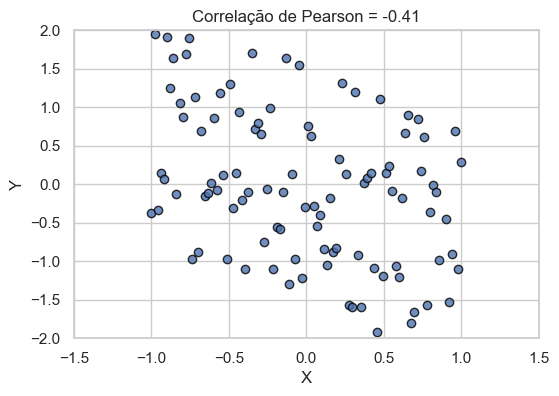

In [34]:
N = 100
X = np.linspace(-1, 1, N)
ruido_base = np.random.uniform(-1, 1, N)

for sigma in [0.0, 0.4, 0.8, 1.2, 1.6]:
    Y = -0.8 * X + sigma * ruido_base
    corr, p_value = pearsonr(X, Y)

    plt.figure(figsize=(6, 4))
    plt.scatter(X, Y, edgecolor="black", alpha=0.8)
    plt.title(f"Correlação de Pearson = {corr:.2f}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(-1.5, 1.5)
    plt.ylim(-2, 2)
    plt.show()

À medida que o ruído aumenta, a relação linear entre as variáveis fica menos evidente, e a correlação se aproxima de zero.


### 6.2 Matriz de correlação

Quando temos várias variáveis, podemos calcular uma matriz de correlação. Cada entrada da matriz mostra a correlação entre um par de variáveis.


          x         y         z
x  1.000000  0.518457 -0.701886
y  0.518457  1.000000 -0.860941
z -0.701886 -0.860941  1.000000


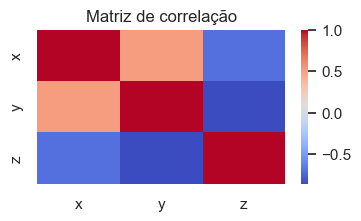

In [46]:
exemplo = pd.DataFrame({
    "x": [45, 37, 42, 35, 39],
    "y": [38, 31, 26, 28, 33],
    "z": [10, 15, 17, 21, 12]
})

corr = exemplo.corr()
print(corr)

plt.figure(figsize=(4, 2))
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlação")
plt.show()

### 6.3 Correlação entre variáveis da base Iris

Agora calculamos a matriz de correlação para as quatro variáveis numéricas da base Iris.


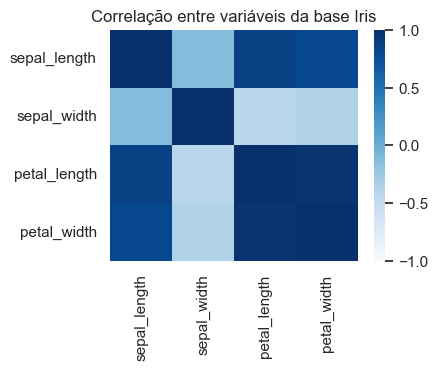

In [48]:
variaveis_numericas = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
corr_iris = data[variaveis_numericas].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr_iris, annot=False, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis da base Iris")
plt.show()

### 6.4 Pair plot

O pair plot mostra gráficos de dispersão entre todos os pares de variáveis. Na diagonal, aparecem distribuições univariadas. Esse gráfico é muito útil para uma primeira inspeção de uma base de dados multivariada.


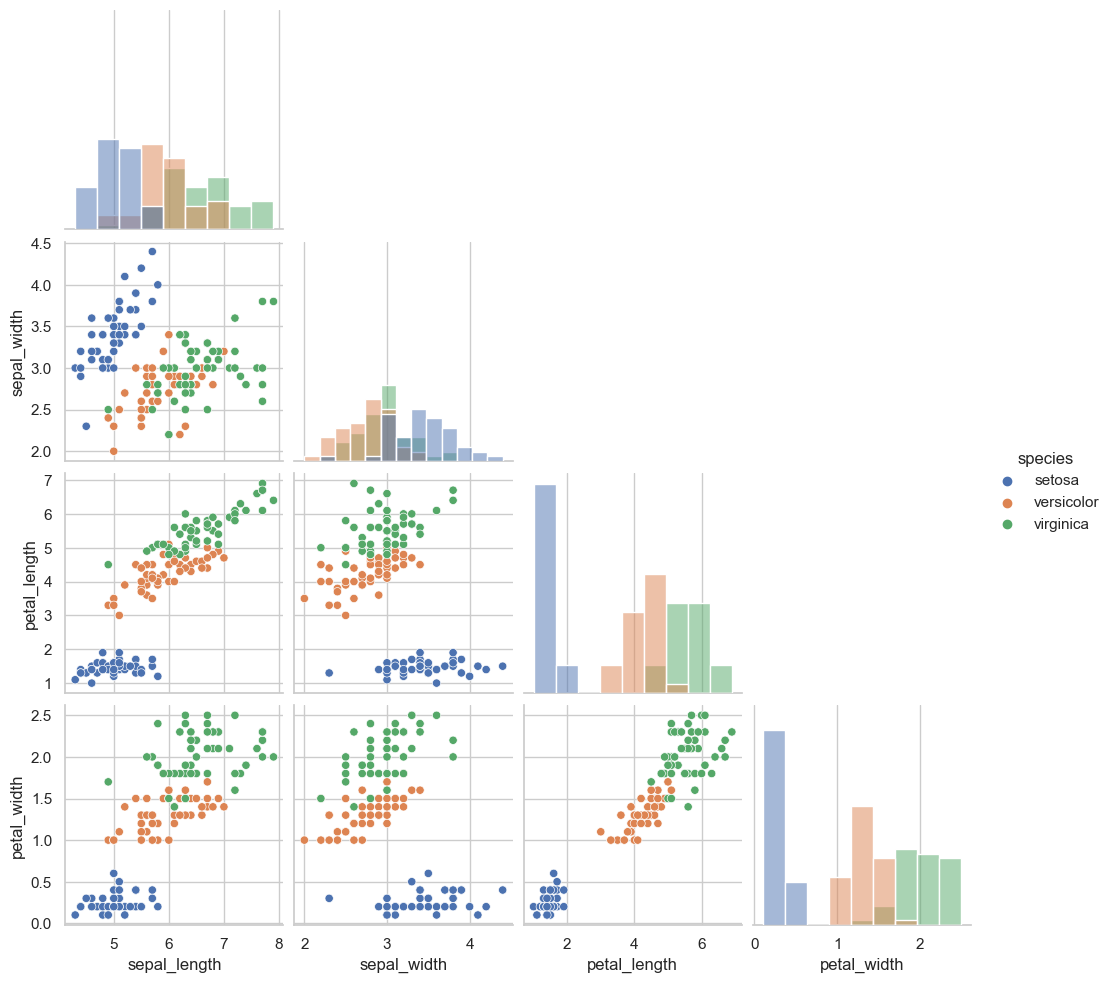

In [49]:
import warnings
warnings.filterwarnings('ignore')

sns.pairplot(
    data,
    vars=variaveis_numericas,
    hue="species",
    diag_kind="hist",
    corner=True
)
plt.show()

### 6.5 Correlação de Spearman

A correlação de Spearman não usa diretamente os valores originais, mas sim os **postos** (*ranks*) desses valores. Por isso, ela mede associações monotônicas, mesmo quando a relação não é linear.


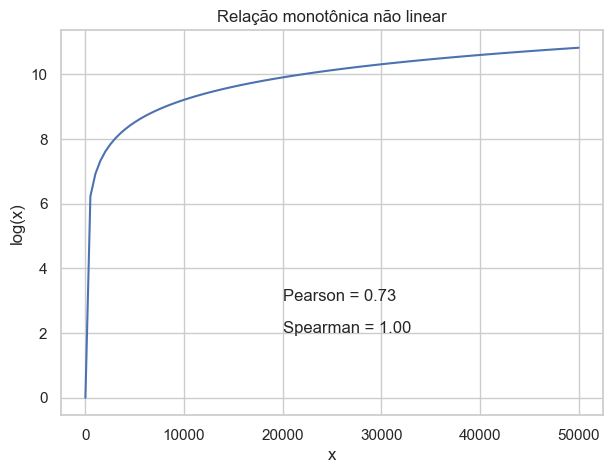

Correlação de Pearson: 0.7291539573607199
Correlação de Spearman: 0.9999999999999999


In [50]:
x = np.linspace(1, 50000, 100)
z = np.log(x)

corr_pearson, _ = pearsonr(x, z)
corr_spearman, _ = spearmanr(x, z)

plt.figure(figsize=(7, 5))
plt.plot(x, z)
plt.xlabel("x")
plt.ylabel("log(x)")
plt.title("Relação monotônica não linear")
plt.text(20000, 3, f"Pearson = {corr_pearson:.2f}", fontsize=12)
plt.text(20000, 2, f"Spearman = {corr_spearman:.2f}", fontsize=12)
plt.show()

print("Correlação de Pearson:", corr_pearson)
print("Correlação de Spearman:", corr_spearman)

Nesse exemplo, a relação entre `x` e `log(x)` é perfeitamente crescente, mas não é linear. Por isso, a correlação de Spearman é igual a 1, enquanto a correlação de Pearson é menor que 1.


## 7. Implementação manual das correlações

Para entender melhor as medidas de correlação, vamos implementar algumas funções manualmente. Essa etapa é didática: na prática, usamos funções prontas como `pearsonr`, `spearmanr` ou `DataFrame.corr()`.


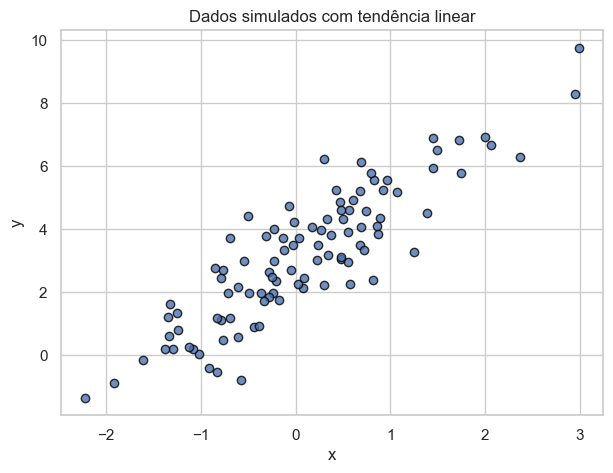

In [51]:
x = np.random.normal(0, 1, 100)
y = 2 * x + 3 + np.random.normal(0, 1, 100)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, edgecolor="black", alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dados simulados com tendência linear")
plt.show()

In [52]:
def desvio_padrao_populacional(vetor):
    # Calcula o desvio-padrão populacional.
    vetor = np.asarray(vetor)
    media = np.mean(vetor)
    return np.sqrt(np.mean((vetor - media) ** 2))

print("Função implementada:", desvio_padrao_populacional(x))
print("NumPy:", np.std(x))

Função implementada: 0.984391470529612
NumPy: 0.984391470529612


In [53]:
def pearson_manual(x, y):
    # Calcula a correlação de Pearson manualmente.
    x = np.asarray(x)
    y = np.asarray(y)

    covariancia = np.mean((x - np.mean(x)) * (y - np.mean(y)))
    return covariancia / (np.std(x) * np.std(y))

print("Pearson manual:", pearson_manual(x, y))
print("Pearson usando scipy:", pearsonr(x, y)[0])

Pearson manual: 0.879955717892098
Pearson usando scipy: 0.879955717892098


Para calcular Spearman, basta transformar os valores em postos e aplicar a correlação de Pearson aos postos.


In [54]:
x_rank = pd.Series(x).rank().to_numpy()
y_rank = pd.Series(y).rank().to_numpy()

print("Spearman manual:", pearson_manual(x_rank, y_rank))
print("Spearman usando scipy:", spearmanr(x, y)[0])

Spearman manual: 0.8539213921392139
Spearman usando scipy: 0.8539213921392139


## 8. Por que gráficos são indispensáveis?

Medidas estatísticas podem ser iguais ou muito parecidas para conjuntos de dados com padrões completamente diferentes. Um exemplo clássico é o **quarteto de Anscombe**.

Os quatro conjuntos abaixo têm médias, variâncias e correlações semelhantes, mas estruturas visuais muito diferentes.


In [59]:
x1 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
y1 = [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]
y2 = [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]
y3 = [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]
x4 = [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8]
y4 = [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]

anscombe = {
    "I": (x1, y1),
    "II": (x1, y2),
    "III": (x1, y3),
    "IV": (x4, y4)
}

resumo = []
for nome, (xx, yy) in anscombe.items():
    resumo.append({
        "conjunto": nome,
        "media_x": np.mean(xx),
        "media_y": np.mean(yy),
        "var_x": np.var(xx, ddof=1),
        "var_y": np.var(yy, ddof=1),
        "correlacao": pearsonr(xx, yy)[0]
    })

pd.DataFrame(resumo)

,conjunto,media_x,media_y,var_x,var_y,correlacao
0,I,9.0,7.500909,11.0,4.127269,0.816421
1,II,9.0,7.500909,11.0,4.127629,0.816237
2,III,9.0,7.500000,11.0,4.122620,0.816287
3,IV,9.0,7.500909,11.0,4.123249,0.816521


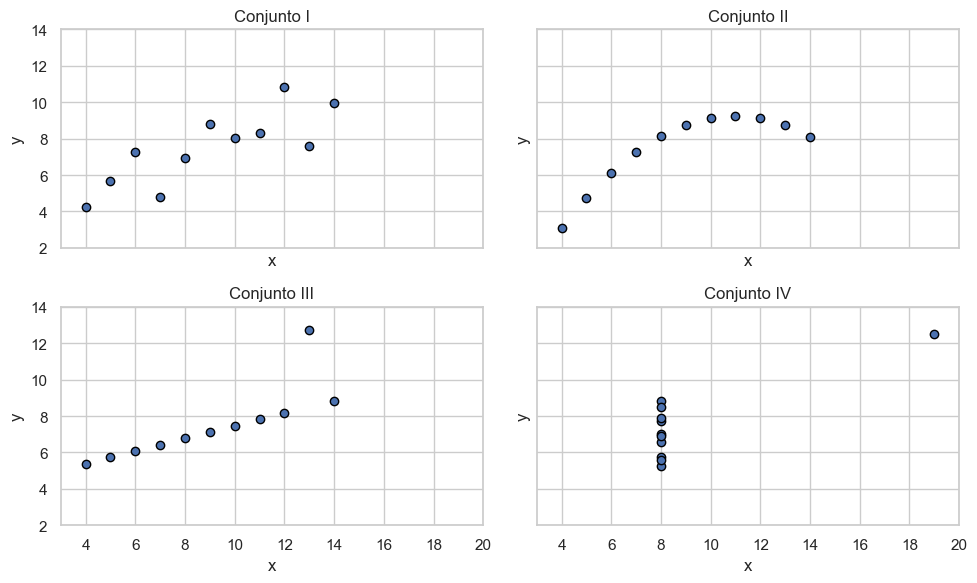

In [60]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 6))

for ax, (nome, (xx, yy)) in zip(axs.flat, anscombe.items()):
    ax.scatter(xx, yy, edgecolor="black")
    ax.set_title(f"Conjunto {nome}")
    ax.set_xlim(3, 20)
    ax.set_ylim(2, 14)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

O quarteto de Anscombe mostra uma lição importante: **nunca devemos analisar dados apenas por medidas-resumo**. A visualização é essencial para revelar padrões, curvaturas, agrupamentos e valores extremos.


## 9. Exercícios de fixação

1. Gere amostras de distribuições de Poisson com diferentes valores de $\lambda$. Para cada amostra, calcule a média e o desvio-padrão. Em seguida, faça um gráfico da média em função do desvio-padrão. O que você observa?

2. Considere a base Iris. Calcule, para cada variável numérica, a média, a variância, o desvio-padrão e o intervalo interquartil.

3. Obtenha o boxplot de todas as variáveis da base Iris, separando os resultados por espécie.

4. Calcule a matriz de correlação de Pearson da base Iris. Quais pares de variáveis possuem maior correlação positiva?

5. Calcule a matriz de correlação de Spearman da base Iris. Os resultados são semelhantes aos obtidos com Pearson?

6. Escolha uma base de dados real de seu interesse e realize uma análise exploratória inicial contendo: resumo estatístico, histogramas, boxplots e matriz de correlação.


### Exemplo de solução parcial do Exercício 1

O código abaixo ilustra como podemos investigar a relação entre média e desvio-padrão em distribuições de Poisson.


In [ ]:
medias = []
desvios = []

for lamb in range(1, 20):
    amostra = np.random.poisson(lam=lamb, size=1000)
    medias.append(np.mean(amostra))
    desvios.append(np.std(amostra))

plt.figure(figsize=(7, 5))
plt.scatter(medias, desvios, edgecolor="black")
plt.xlabel("Média amostral")
plt.ylabel("Desvio-padrão amostral")
plt.title("Distribuição de Poisson: média versus desvio-padrão")
plt.show()

Na distribuição de Poisson, a média teórica é igual à variância teórica. Portanto, o desvio-padrão cresce aproximadamente como a raiz quadrada da média.
